<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>
In The Name of God
</font>
<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Introduction to Machine Learning
</font>
<hr/>
<font color="#800080" size=5>
Phase 1
<br>
</font>
<font size=5>
Instructor: Dr. S. Amini
<br>
</font>
<font size=4>
Fall 2025
<br>
</font>
<font face="Times New Roman" size=4>
</font>
<hr>
<font color='red'  size=4>
<br>
</font>
<font face="Times New Roman" size=4 align=center>
Feel free to ask your questions in Telegram : @ZahraSorkhei
</font>
<br>
<hr>
</div></font>

# GMM and OOD Detection

In this notebook, you will implement a Gaussian Mixture Model (GMM) from scratch using the EM algorithm and use it for Out-of-Distribution (OOD) detection. We will start with 2D data and later extend to 3D.


## 1. Multivariate Gaussian PDF

First, we define a helper function to compute the multivariate Gaussian probability density function.

Complete the function below:


In [1]:
import numpy as np

def gaussian_pdf(x, mean, cov):
    # TODO: Compute the dimension of x
    d = x.shape[0]

    # TODO: Compute the difference between x and mean
    diff = x - mean

    # TODO: Compute inverse and determinant of covariance
    inv_cov = np.linalg.inv(cov)
    det_cov = np.linalg.det(cov)

    # TODO: Compute normalization constant
    norm_const = 1.0 / np.sqrt((2 * np.pi) ** d * det_cov)

    # TODO: Compute exponent term
    exp_term = np.exp(-0.5 * diff.T @ inv_cov @ diff)

    return norm_const * exp_term


## 2. Implement GMM Class with EM

We will implement a GMM class with the EM algorithm.


In [2]:
class GMM:
    def __init__(self, n_components, max_iters=100, tol=1e-3):
        self.K = n_components
        self.max_iters = max_iters
        self.tol = tol

    def initialize(self, X):
        n, d = X.shape
        rng = np.random.default_rng()

        # TODO: Initialize means randomly from X
        self.means = X[rng.choice(n, self.K, replace=False)]

        # TODO: Initialize covariance matrices
        self.covs = np.array([np.eye(d) for _ in range(self.K)])

        # TODO: Initialize mixture weights
        self.weights = np.ones(self.K) / self.K

    def e_step(self, X):
        n = X.shape[0]
        gamma = np.zeros((n, self.K))

        # TODO: Compute responsibilities
        for k in range(self.K):
            gamma[:, k] = self.weights[k] * np.array([gaussian_pdf(x, self.means[k], self.covs[k]) for x in X])

        # TODO: Normalize responsibilities
        gamma /= np.sum(gamma, axis=1, keepdims=True)
        return gamma

    def m_step(self, X, gamma):
        n, d = X.shape
        Nk = np.sum(gamma, axis=0) #: Sum responsibilities for each component

        # TODO: Update weights
        self.weights = Nk / n

        # TODO: Update means
        self.means = (gamma.T @ X) / Nk[:, None]

        # TODO: Update covariances
        self.covs = np.zeros((self.K, d, d))
        for k in range(self.K):
            diff = X - self.means[k]
            self.covs[k] = (gamma[:, k][:, None] * diff).T @ diff / Nk[k]
            self.covs[k] += 1e-6 * np.eye(d)

    def log_likelihood(self, X):
        # TODO: Compute log-likelihood for each sample
        n = X.shape[0]
        ll = np.zeros(n)
        for i in range(n):
            prob = 0
            for k in range(self.K):
                prob += self.weights[k] * gaussian_pdf(X[i], self.means[k], self.covs[k])
            ll[i] = np.log(prob + 1e-12)

        return ll

    def fit(self, X):
        self.initialize(X)
        prev_ll = None

        for i in range(self.max_iters):
            # TODO: E-step
            gamma = self.e_step(X)

            # TODO: M-step
            self.m_step(X, gamma)

            # TODO: Compute mean log-likelihood
            ll = np.mean(self.log_likelihood(X))

            # Check for convergence
            if prev_ll is not None and abs(ll - prev_ll) < self.tol:
                break
            prev_ll = ll

        print(f"EM converged in {i+1} iterations")


## 3. Generate Toy 2D Data

Generate a 2D dataset with two Gaussian clusters (ID data) and some uniform OOD points.


In [3]:
np.random.seed(0)

# ID data (mixture of Gaussians)
N = 600
X1 = np.random.multivariate_normal([0, 0], [[0.8, 0.2], [0.2, 0.6]], N // 2)
X2 = np.random.multivariate_normal([3, 3], [[0.6, -0.1], [-0.1, 0.6]], N // 2)
X_id = np.vstack([X1, X2])

# OOD data (far away)
X_ood = np.random.uniform(low=-6, high=6, size=(200, 2))


## 4. Train GMM on ID Data

Use your implemented GMM class to fit the ID dataset.


In [4]:
# TODO: Initialize GMM with 2 components
gmm = GMM(n_components=2)

# TODO: Fit GMM
gmm.fit(X_id)


EM converged in 2 iterations


## 5. OOD Detection

Compute log-likelihoods for ID and OOD points, and detect OOD points using a threshold.


In [5]:
# TODO: Compute log-likelihoods for ID and OOD data
ll_id = gmm.log_likelihood(X_id)
ll_ood = gmm.log_likelihood(X_ood)

# TODO: Set threshold
threshold = np.percentile(ll_id, 5)

# TODO: Make predictions
pred_id = ll_id >= threshold
pred_ood = ll_ood >= threshold


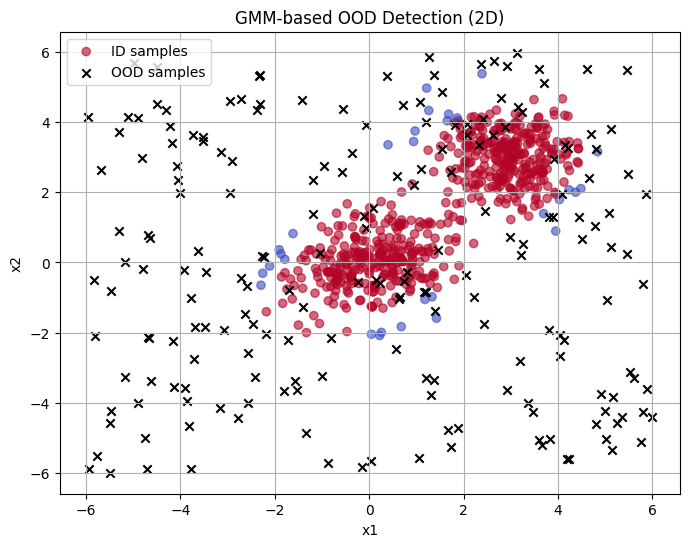

In [6]:
import matplotlib.pyplot as plt
# =========================
# Visualization
# =========================
plt.figure(figsize=(8, 6))
plt.scatter(X_id[:, 0], X_id[:, 1],
            c=pred_id, cmap="coolwarm", alpha=0.6, label="ID samples")
plt.scatter(X_ood[:, 0], X_ood[:, 1],
            c="black", marker="x", label="OOD samples")
plt.legend()
plt.title("GMM-based OOD Detection (2D)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

# GMM Image Segmentation

In this notebook, you will apply Gaussian Mixture Models (GMM) with EM algorithm to perform clustering-based segmentation on color images. You will work with 3-channel images (RGB).

## 1. Gaussian PDF Function

Complete the multivariate Gaussian PDF function. This function will be used in the EM algorithm.


In [1]:
import numpy as np

def gaussian_pdf(X, mean, cov):
    d = X.shape[1]
    diff = X - mean            
    inv_cov = np.linalg.inv(cov)
    det_cov = np.linalg.det(cov)

    mahalanobis = np.sum(diff @ inv_cov * diff, axis=1)

    norm_const = 1.0 / np.sqrt((2 * np.pi) ** d * det_cov)
    pdf = norm_const * np.exp(-0.5 * mahalanobis)

    return pdf


## 2. Implement GMM Class with EM

Fill in the missing parts for the GMM class.


In [2]:
class GMM:
    def __init__(self, n_components, max_iters=40, tol=1e-3):
        self.K = n_components
        self.max_iters = max_iters
        self.tol = tol

    def initialize(self, X):
        n, d = X.shape
        rng = np.random.default_rng()

        indices = rng.choice(n, self.K, replace=False)
        self.means = X[indices]

        self.covs = np.array([np.eye(d) for _ in range(self.K)])
        self.weights = np.ones(self.K) / self.K

    def e_step(self, X):
        n = X.shape[0]
        gamma = np.zeros((n, self.K))

        for k in range(self.K):
            gamma[:, k] = self.weights[k] * gaussian_pdf(
                X, self.means[k], self.covs[k]
            )

        gamma_sum = np.sum(gamma, axis=1, keepdims=True) + 1e-12
        gamma /= gamma_sum

        return gamma

    def m_step(self, X, gamma):
        n, d = X.shape
        Nk = np.sum(gamma, axis=0) + 1e-12

        self.weights = Nk / n
        self.means = (gamma.T @ X) / Nk[:, None]

        self.covs = np.zeros((self.K, d, d))
        eps = 1e-6

        for k in range(self.K):
            diff = X - self.means[k]
            self.covs[k] = (gamma[:, k][:, None] * diff).T @ diff / Nk[k]
            self.covs[k] += eps * np.eye(d)

    def fit(self, X):
        self.initialize(X)
        prev_ll = None

        for _ in range(self.max_iters):
            gamma = self.e_step(X)
            self.m_step(X, gamma)

            ll = 0
            for k in range(self.K):
                ll += self.weights[k] * gaussian_pdf(
                    X, self.means[k], self.covs[k]
                )
            ll = np.sum(np.log(ll + 1e-12))

            if prev_ll is not None and abs(ll - prev_ll) < self.tol:
                break
            prev_ll = ll

    def predict(self, X):
        gamma = self.e_step(X)
        return np.argmax(gamma, axis=1)


## 3. Segment Image Function

In [ ]:
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def segment_image(image, K, title):

    # TODO: Resize the image to 256x256
    image = cv2.resize(image, (256, 256))


    # TODO: If grayscale, convert to 3-channel RGB
    if image.ndim == 2:
        image = np.stack([image, image, image], axis=-1)

    H, W, _ = image.shape

    # TODO: Reshape image to N x 3 for GMM
    X = image.reshape(-1, 3).astype(np.float64) / 255.0

    # TODO: Initialize GMM and fit to pixel data
    gmm = GMM(n_components=K)
    # TODO: Fit GMM
    gmm.fit(X)

    # TODO: Predict cluster labels and reshape labels back to H x W
    labels = gmm.predict(X)
    label_map = labels.reshape(H, W)

    # fixed colormap
    cmap = plt.get_cmap("tab10", K)

    # TODO: Create legend handles for each cluster
    legend_elements = [
        Patch(facecolor=cmap(i), label=f"Cluster {i}")
        for i in range(K)
    ]

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title(f"Original – {title}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(label_map, cmap=cmap)
    plt.title("GMM Segmentation (Labels)")
    plt.axis("off")
    plt.legend(handles=legend_elements,
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            borderaxespad=0.)

    plt.tight_layout()
    plt.show()


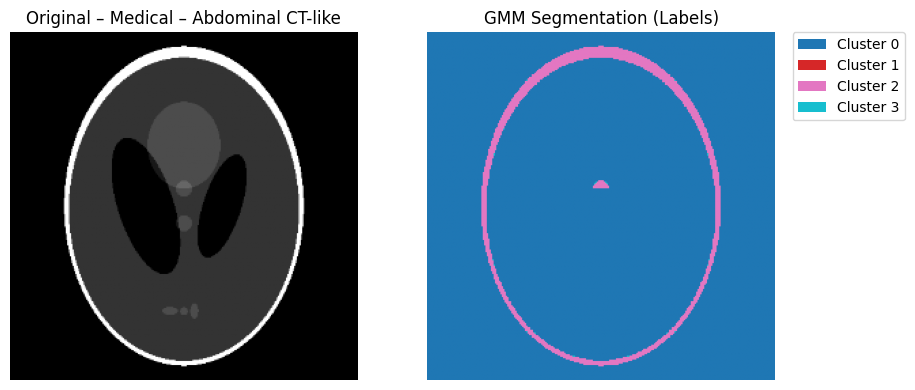

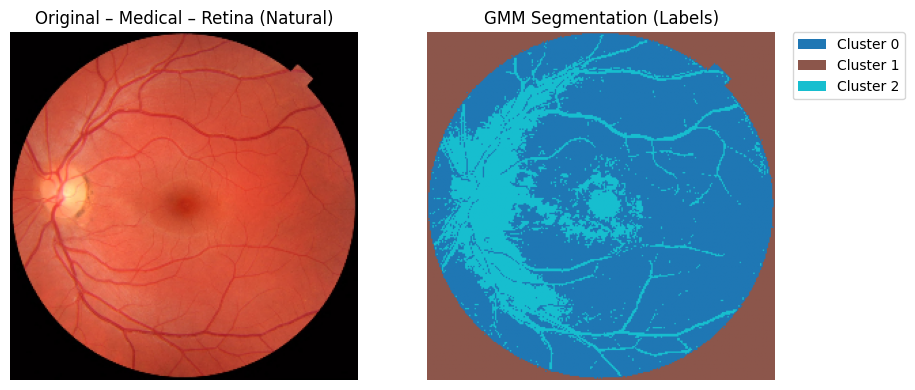

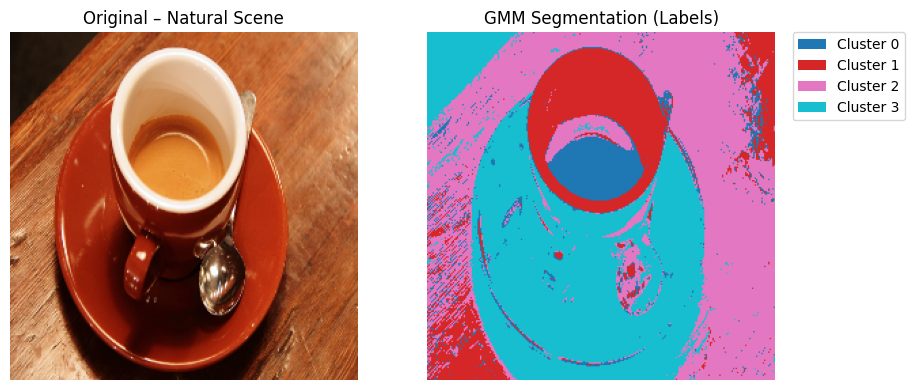

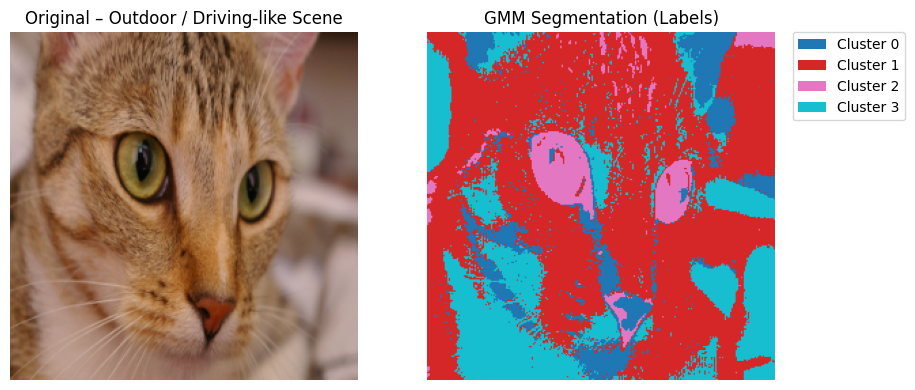

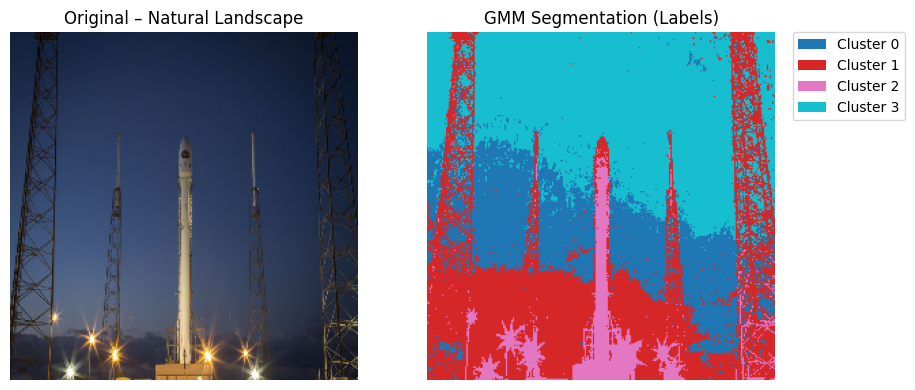

In [4]:
# =========================
# Run experiments
# =========================
from skimage import data

segment_image(data.shepp_logan_phantom(), 4,
              "Medical – Abdominal CT-like")

segment_image(data.retina(),  K=3, title="Medical – Retina (Natural)")

segment_image(data.coffee(), 4,
              "Natural Scene")

segment_image(data.chelsea(), 4,
              "Outdoor / Driving-like Scene")

segment_image(data.rocket(), 4,
              "Natural Landscape")
